In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd
import numpy as np
file_exp1 = "Stats checkpoints - experiment 1.csv" # these are just sheets exported in csv
file_exp2 = "Stats checkpoints - experiment 2.csv"

def get_process_averages(file_path):
    df = pd.read_csv(file_path, header=[1, 2])
    results = {}

    def avg_group_ingestion(start_col, end_col):
        group_data = df.iloc[0:4, start_col:end_col+1].astype(float)
        return group_data.mean(axis=1).tolist()

    def avg_group_querying(start_col, end_col):
        group_data = df.iloc[8:12, start_col:end_col+1].astype(float)
        return group_data.mean(axis=1).tolist()

    results['query_i'] = avg_group_ingestion(5, 8)
    results['RDF4J_i'] = avg_group_ingestion(9, 12)
    results['registry_i'] = avg_group_ingestion(13, 16)
    results['Mongo_i'] = avg_group_ingestion(17, 20)

    results['query_q'] = avg_group_querying(5, 8)
    results['RDF4J_q'] = avg_group_querying(9, 12)
    results['registry_q'] = avg_group_querying(13, 16)
    results['Mongo_q'] = avg_group_querying(17, 20)

    return results

experiment_1 = get_process_averages(file_exp1)
experiment_2 = get_process_averages(file_exp2)

In [4]:
experiment_1

{'query_i': [9.912500000000001, 9.22, 8.825, 7.8325],
 'RDF4J_i': [46.1275, 41.5425, 48.324999999999996, 51.25],
 'registry_i': [20.3425, 20.314999999999998, 19.625, 18.25],
 'Mongo_i': [58.035, 72.685, 87.0, 92.4],
 'query_q': [36.0, 37.1, 37.9, 37.375],
 'RDF4J_q': [340.0, 229.5, 280.0, 158.5],
 'registry_q': [3.4875000000000003, 1.235, 1.0, 0.7224999999999999],
 'Mongo_q': [38.55, 79.425, 96.525, 96.575]}

In [5]:
experiment_2

{'query_i': [8.6325, 9.1125, 8.415000000000001, 7.362500000000001],
 'RDF4J_i': [31.2, 37.225, 35.975, 25.4],
 'registry_i': [21.700000000000003, 22.125, 19.95, 20.475],
 'Mongo_i': [65.625, 70.025, 76.95, 89.55000000000001],
 'query_q': [29.725, 31.05, 31.875, 30.9],
 'RDF4J_q': [131.0, 222.75, 129.5, 140.5],
 'registry_q': [1.865, 1.9075000000000002, 1.4649999999999999, 0.89],
 'Mongo_q': [26.25, 37.75, 69.025, 83.475]}

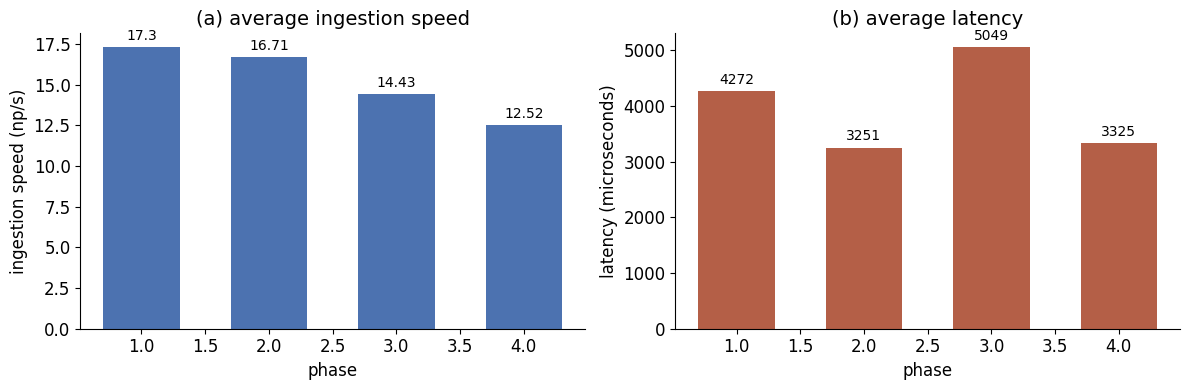

In [6]:
# ingestion and latency speed

phase = [1, 2, 3, 4]
ingestion_speed = [17.30, 16.71, 14.43, 12.52]
latencies = [4272,  3251,  5049, 3325]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars1 = ax1.bar(phase, ingestion_speed, color='#4c72b0', width=0.6)
ax1.set_title('(a) average ingestion speed', fontsize=14)
ax1.set_xlabel('phase', fontsize=12)
ax1.set_ylabel('ingestion speed (np/s)', fontsize=12)
ax1.bar_label(bars1, padding=3)

bars2 = ax2.bar(phase, latencies, color='#b45f47', width=0.6)
ax2.set_title('(b) average latency', fontsize=14)
ax2.set_xlabel('phase', fontsize=12)
ax2.set_ylabel('latency (microseconds)', fontsize=12)
ax2.bar_label(bars2, padding=3)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

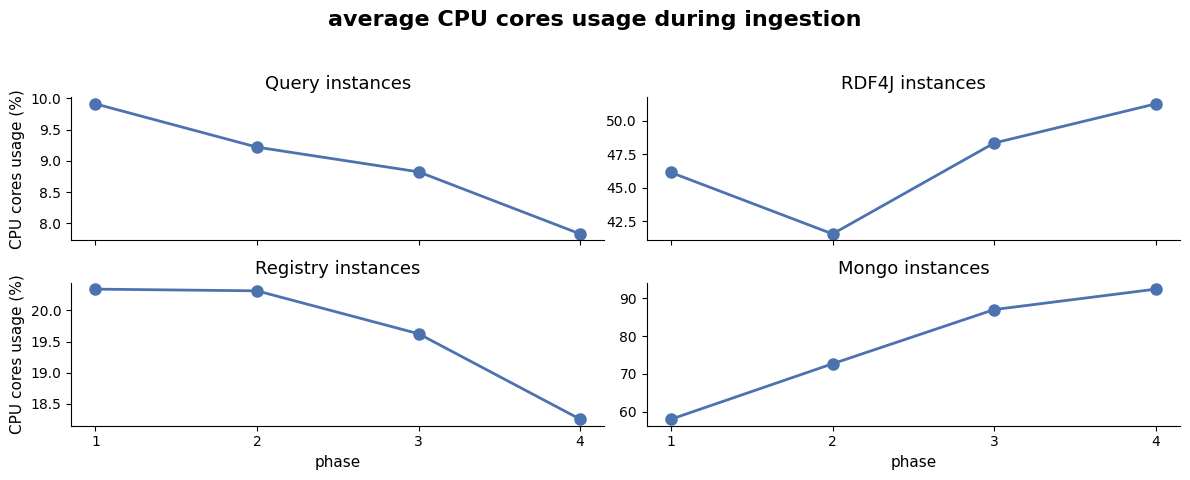

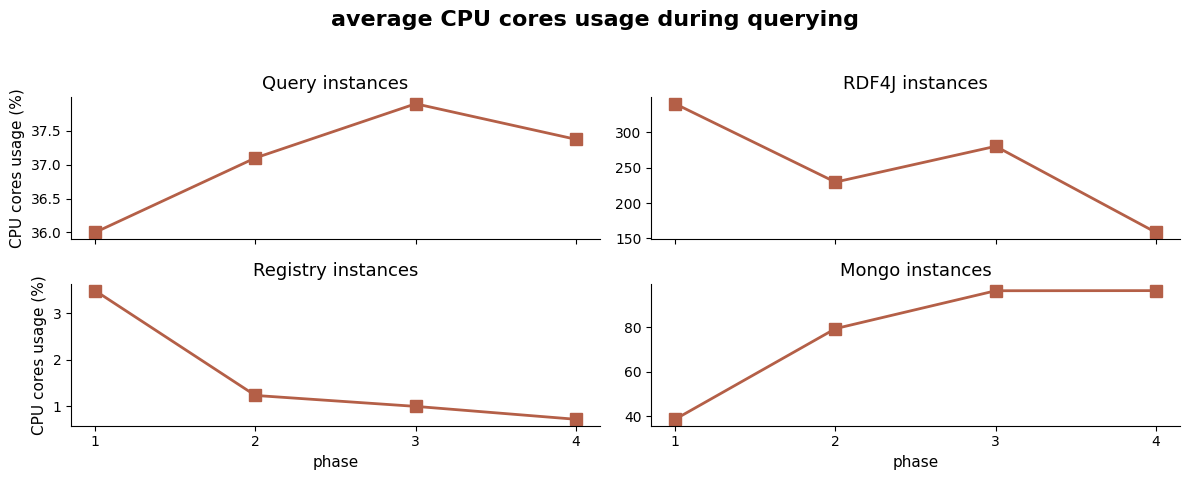

In [7]:
import matplotlib.pyplot as plt

phases = [1, 2, 3, 4]
data = [
    [experiment_1["query_i"], experiment_1["query_q"]],
    [experiment_1["RDF4J_i"], experiment_1["RDF4J_q"]],
    [experiment_1["registry_i"], experiment_1["registry_q"]],
    [experiment_1["Mongo_i"], experiment_1["Mongo_q"]]
]

titles = ["Query instances", "RDF4J instances", "Registry instances", "Mongo instances"]
colors = {'ingestion': '#4c72b0', 'querying': '#b45f47'}

def create_split_plot(workload_index, label, color, marker):
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
    fig.suptitle(f'average CPU cores usage during {label}', fontsize=16, fontweight='bold')
    axes_flat = axes.flatten()

    for i, ax in enumerate(axes_flat):
        ax.plot(phases, [obs[workload_index] for obs in [data[i]]][0],
                label=label, color=color, marker=marker, linewidth=2, markersize=8)

        ax.set_title(titles[i], fontsize=13)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if i % 2 == 0:
            ax.set_ylabel('CPU cores usage (%)', fontsize=11)
        if i >= 2:
            ax.set_xlabel('phase', fontsize=11)
            ax.set_xticks(phases)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

fig_ingestion = create_split_plot(0, 'ingestion', colors['ingestion'], 'o')

fig_querying = create_split_plot(1, 'querying', colors['querying'], 's')

plt.show()

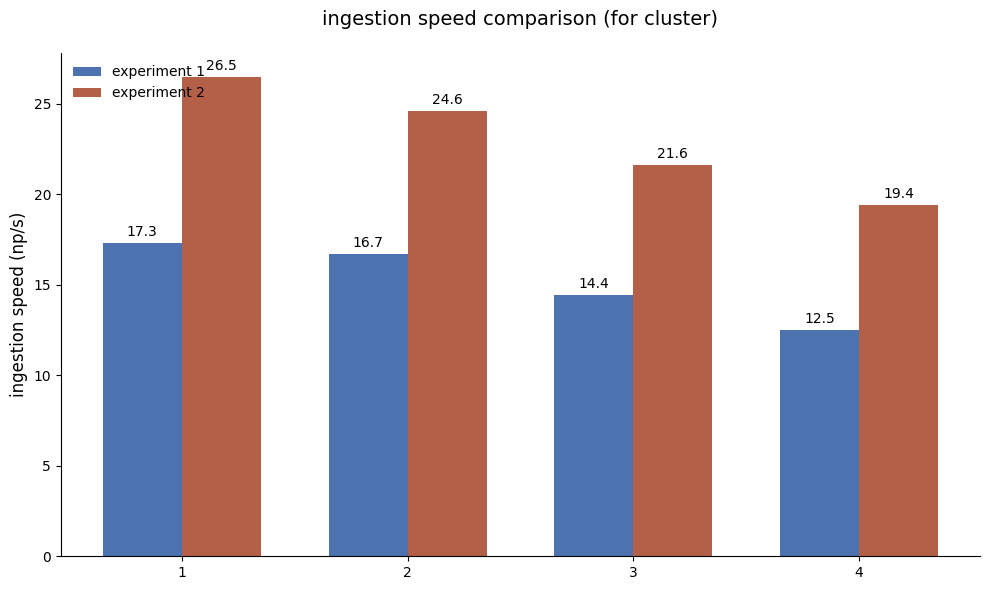

In [9]:
phases = [1, 2, 3, 4]
values_exp1 = [17.30, 16.71, 14.43, 12.52]
values_exp2 = [26.5, 24.59, 21.6, 19.43]

x = np.arange(len(phases))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, values_exp1, width, label='experiment 1', color='#4c72b0')
rects2 = ax.bar(x + width/2, values_exp2, width, label='experiment 2', color='#b45f47')

ax.set_ylabel('ingestion speed (np/s)', fontsize=12)
ax.set_title('ingestion speed comparison (for cluster)', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(phases)
ax.legend(frameon=False, loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()

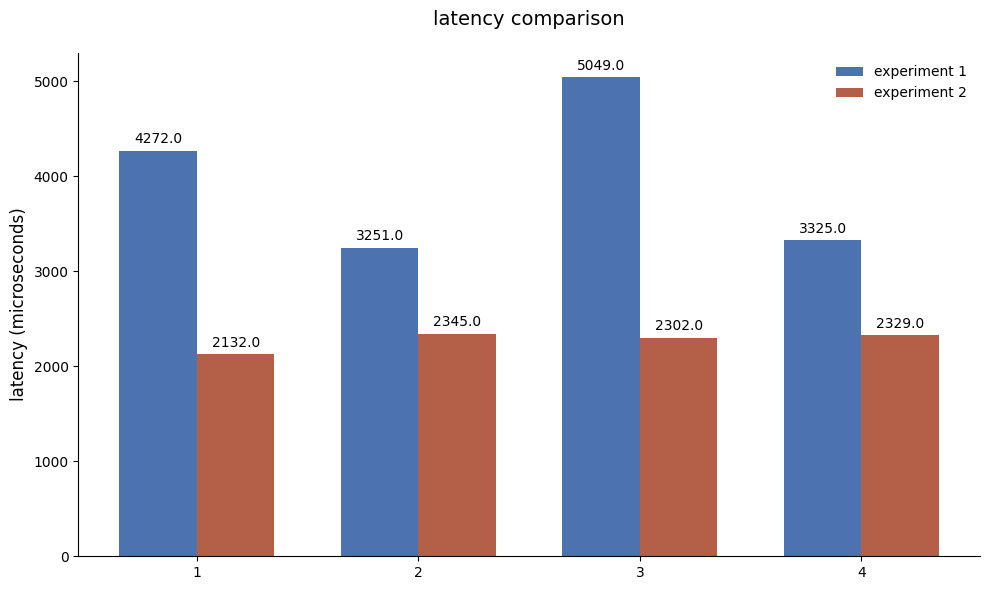

In [10]:
phases = [1, 2, 3, 4]
values_exp1 = [4272, 3251, 5049, 3325]
values_exp2 = [2132, 2345, 2302, 2329]

x = np.arange(len(phases))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, values_exp1, width, label='experiment 1', color='#4c72b0')
rects2 = ax.bar(x + width/2, values_exp2, width, label='experiment 2', color='#b45f47')

ax.set_ylabel('latency (microseconds)', fontsize=12)
ax.set_title('latency comparison', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(phases)
ax.legend(frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()

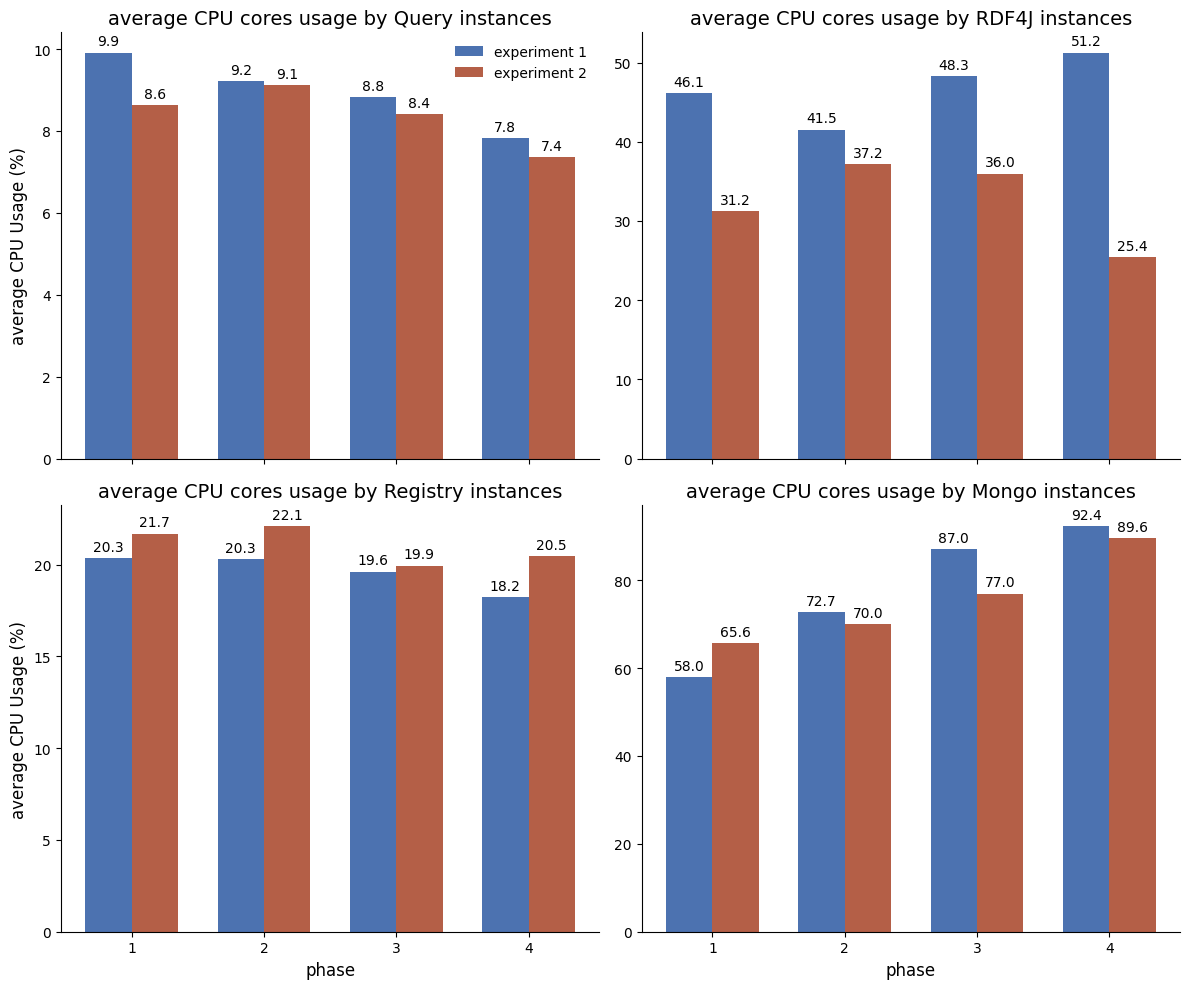

In [11]:
# during ingestion

phases = [1, 2, 3, 4]
data = [[experiment_1["query_i"], experiment_2["query_i"]],
    [experiment_1["RDF4J_i"], experiment_2["RDF4J_i"]],
    [experiment_1["registry_i"], experiment_2["registry_i"]],
    [experiment_1["Mongo_i"], experiment_2["Mongo_i"]]
]

titles = ["average CPU cores usage by Query instances", "average CPU cores usage by RDF4J instances",
"average CPU cores usage by Registry instances", "average CPU cores usage by Mongo instances"]

line_labels = ['experiment 1', 'experiment 2']
colors = ['#4c72b0', '#b45f47']

x = np.arange(len(phases))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    rects1 = ax.bar(x - width/2, data[i][0], width, label=line_labels[0], color=colors[0])

    rects2 = ax.bar(x + width/2, data[i][1], width, label=line_labels[1], color=colors[1])

    ax.set_title(titles[i], fontsize=14, fontweight='medium')
    ax.set_xticks(x)
    ax.set_xticklabels(phases)

    ax.bar_label(rects1, padding=3, fmt='%.1f', fontsize=10)
    ax.bar_label(rects2, padding=3, fmt='%.1f', fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if i == 0:
        ax.legend(frameon=False)
    if i >= 2:
        ax.set_xlabel('phase', fontsize=12)
    if i % 2 == 0:
        ax.set_ylabel('average CPU Usage (%)', fontsize=12)

plt.tight_layout()
plt.show()

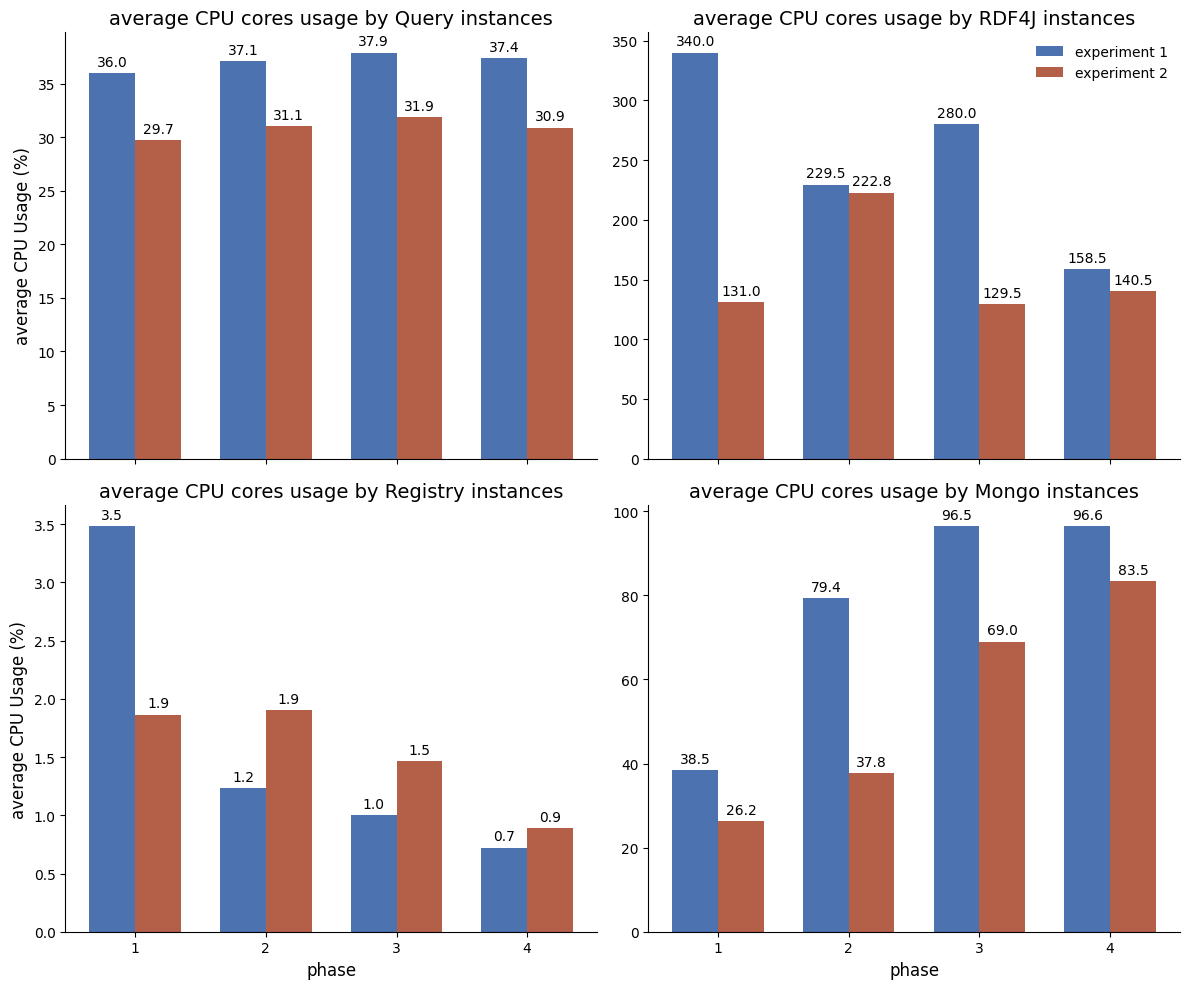

In [12]:
# during querying

phases = [1, 2, 3, 4]
data = [[experiment_1["query_q"], experiment_2["query_q"]],
    [experiment_1["RDF4J_q"], experiment_2["RDF4J_q"]],
    [experiment_1["registry_q"], experiment_2["registry_q"]],
    [experiment_1["Mongo_q"], experiment_2["Mongo_q"]]
]

titles = ["average CPU cores usage by Query instances", "average CPU cores usage by RDF4J instances",
"average CPU cores usage by Registry instances", "average CPU cores usage by Mongo instances"]

line_labels = ['experiment 1', 'experiment 2']
colors = ['#4c72b0', '#b45f47']

x = np.arange(len(phases))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    rects1 = ax.bar(x - width/2, data[i][0], width, label=line_labels[0], color=colors[0])

    rects2 = ax.bar(x + width/2, data[i][1], width, label=line_labels[1], color=colors[1])

    ax.set_title(titles[i], fontsize=14, fontweight='medium')
    ax.set_xticks(x)
    ax.set_xticklabels(phases)

    ax.bar_label(rects1, padding=3, fmt='%.1f', fontsize=10)
    ax.bar_label(rects2, padding=3, fmt='%.1f', fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if i == 1:
        ax.legend(frameon=False)
    if i >= 2:
        ax.set_xlabel('phase', fontsize=12)
    if i % 2 == 0:
        ax.set_ylabel('average CPU Usage (%)', fontsize=12)

plt.tight_layout()
plt.show()